C:\Users\mikey\AppData\Local\Temp\ipykernel_12196\2116294078.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='latin1')
C:\Users\mikey\AppData\Local\Temp\ipykernel_12196\2116294078.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='latin1')
C:\Users\mikey\AppData\Local\Temp\ipykernel_12196\2116294078.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='latin1')
C:\Users\mikey\AppData\Local\Temp\ipykernel_12196\2116294078.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='latin1')
C:\Users\mikey\AppData\Local\Temp\ipykernel_12196\2116294078.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set lo

quarter
2020Q1     966.000000
2020Q2     943.000000
2020Q3     957.000000
2020Q4    1088.000000
2021Q1     983.000000
2021Q2     990.000000
2021Q3    1008.000000
2021Q4    1144.000000
2022Q1    1067.000000
2022Q2    1047.000000
2022Q3    1101.000000
2022Q4    1148.000000
2023Q1    1157.000000
2023Q2    1088.000000
2023Q3    1101.000000
2023Q4    1192.000000
2024Q1    1195.000000
2024Q2    1131.000000
2024Q3    1144.000000
2024Q4    1169.523561
2025Q1    1147.390112
Freq: Q-DEC, Name: avg_wkly_wage, dtype: float64


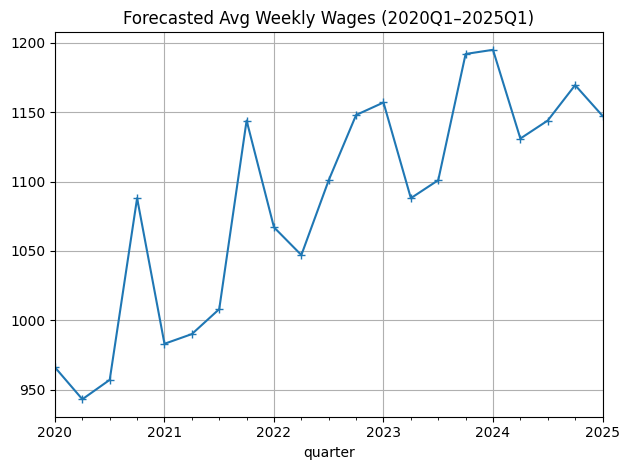

In [2]:
import pandas as pd
import glob
import os
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 📁 경로 설정 (네 드라이브 경로)
path = "G:/내 드라이브/2025-1/경제학연습"

# 📂 모든 q분기별 Employment&Wage 파일 불러오기
file_list = sorted(glob.glob(os.path.join(path, "*q*(Employment&Wage).csv")))

# 📋 CSV 파일들 합치기
dfs = []
for file in file_list:
    df = pd.read_csv(file, encoding='latin1')
    df['source_file'] = os.path.basename(file)
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# 🔎 필터링: 전국(1000), 민간(own_code=5), 전체산업(industry_code=10)
filtered_df = combined_df[
    (combined_df['area_fips'] == 1000) &
    (combined_df['own_code'] == 5) &
    (combined_df['industry_code'] == 10)
]

# 🕐 분기 인덱스 만들기
filtered_df['quarter'] = pd.PeriodIndex(year=filtered_df['year'], quarter=filtered_df['qtr'], freq='Q')
filtered_df.set_index('quarter', inplace=True)

# 📈 평균 주급 시계열 생성
weekly_wages = filtered_df['avg_wkly_wage'].astype(float).sort_index()

# 🔮 ARIMA 예측 (2024Q4, 2025Q1)
model = ARIMA(weekly_wages, order=(1, 1, 1))
model_fit = model.fit()
forecast_arima = model_fit.forecast(steps=2)
forecast_arima.index = ['2024Q4_ARIMA', '2025Q1_ARIMA']

# 📊 전년동기 대비 성장률로 2024Q4 보간
try:
    growth_rate = (weekly_wages['2023Q3'] - weekly_wages['2022Q3']) / weekly_wages['2022Q3']
    base_2023Q4 = weekly_wages['2023Q4']
except KeyError:
    growth_rate = (weekly_wages.iloc[-1] - weekly_wages.iloc[-5]) / weekly_wages.iloc[-5]
    base_2023Q4 = weekly_wages.iloc[-2]

forecast_growth_2024Q4 = base_2023Q4 * (1 + growth_rate)
final_2024Q4 = (forecast_arima['2024Q4_ARIMA'] + forecast_growth_2024Q4) / 2

# 🧩 최종 시계열 확정
weekly_wages = weekly_wages.copy()
weekly_wages['2024Q4'] = final_2024Q4
weekly_wages['2025Q1'] = forecast_arima['2025Q1_ARIMA']

# 📤 출력
print(weekly_wages)

# 📊 시각화
weekly_wages.plot(marker='+', title="Forecasted Avg Weekly Wages (2020Q1–2025Q1)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

# 파일 경로
new_ces_path = "G:/내 드라이브/2025-1/경제학연습/SeriesReport-20250425143031_7e11f9.xlsx"

# 엑셀 읽기 (월 데이터는 12번째 줄부터 시작)
ces_data = pd.read_excel(new_ces_path, skiprows=11)

# 첫 번째 열 이름을 'Year'로 수정
ces_data.rename(columns={ces_data.columns[0]: 'Year'}, inplace=True)

# 2025년 행 필터링
ces_2025 = ces_data[ces_data['Year'] == 2025]

# 2025년 1~3월 주급 평균 (Unnamed: 1 ~ Unnamed: 3)
ces_2025q1_avg = ces_2025[['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']].mean(axis=1).values[0]

# 결과 출력
print(f"✅ 2025년 1분기 CES 평균 주급: ${ces_2025q1_avg:.2f}")


✅ 2025년 1분기 CES 평균 주급: $1227.04


c:\Users\mikey\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


c:\Users\mikey\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\mikey\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


quarter
2020Q1                  966.000000
2020Q2                  943.000000
2020Q3                  957.000000
2020Q4                 1088.000000
2021Q1                  983.000000
2021Q2                  990.000000
2021Q3                 1008.000000
2021Q4                 1144.000000
2022Q1                 1067.000000
2022Q2                 1047.000000
2022Q3                 1101.000000
2022Q4                 1148.000000
2023Q1                 1157.000000
2023Q2                 1088.000000
2023Q3                 1101.000000
2023Q4                 1192.000000
2024Q1                 1195.000000
2024Q2                 1131.000000
2024Q3                 1144.000000
2024Q4                 1171.976730
2025Q1                 1147.390112
2025Q1_ARIMA           1152.418386
2025Q1_CES             1227.040000
2025Q1_Robust_ARIMA    1152.418386
2025Q1_Robust_CES      1227.040000
Name: avg_wkly_wage, dtype: float64


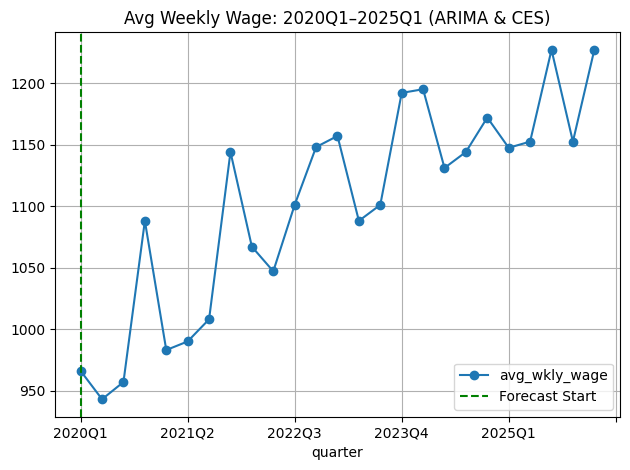


✅ 2025Q1 Robustness Check (ARIMA vs CES)
ARIMA 예측 주급: $1152.42
CES 실측 주급: $1227.04


In [4]:
# 🔮 2. ARIMA 모델로 2024Q4, 2025Q1 예측
model = ARIMA(weekly_wages, order=(1, 1, 1))
model_fit = model.fit()
forecast_arima = model_fit.forecast(steps=2)
forecast_arima.index = ['2024Q4_ARIMA', '2025Q1_ARIMA']

# 📈 3. 2024Q4 전년동기 성장률 기반 보간
try:
    growth_rate = (weekly_wages['2023Q3'] - weekly_wages['2022Q3']) / weekly_wages['2022Q3']
    base_2023Q4 = weekly_wages['2023Q4']
except KeyError:
    growth_rate = (weekly_wages.iloc[-1] - weekly_wages.iloc[-5]) / weekly_wages.iloc[-5]
    base_2023Q4 = weekly_wages.iloc[-2]

forecast_growth_2024Q4 = base_2023Q4 * (1 + growth_rate)
final_2024Q4 = (forecast_arima['2024Q4_ARIMA'] + forecast_growth_2024Q4) / 2

# 📁 4. CES 데이터에서 2025Q1 실측값 가져오기
ces_path = "G:/내 드라이브/2025-1/경제학연습/SeriesReport-20250425143031_7e11f9.xlsx"
ces_data = pd.read_excel(ces_path, skiprows=11)
ces_data.rename(columns={ces_data.columns[0]: 'Year'}, inplace=True)
ces_2025 = ces_data[ces_data['Year'] == 2025]
ces_2025q1_avg = ces_2025[['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']].mean(axis=1).values[0]

# 🧩 5. 최종 QCEW 시계열 확정
weekly_wages = weekly_wages.copy()
weekly_wages['2024Q4'] = final_2024Q4
weekly_wages['2025Q1_ARIMA'] = forecast_arima['2025Q1_ARIMA']
weekly_wages['2025Q1_CES'] = ces_2025q1_avg
# 중복된 인덱스(예: 2024Q4) 제거
weekly_wages = weekly_wages[~weekly_wages.index.duplicated(keep='first')]


# 🧠 6. 정책효과 robustness 체크
# 2025Q1 두 버전: ARIMA 기준 / CES 기준
weekly_wages['2025Q1_Robust_ARIMA'] = forecast_arima['2025Q1_ARIMA']
weekly_wages['2025Q1_Robust_CES'] = ces_2025q1_avg

# 📤 출력
print(weekly_wages)

# 📊 시각화
weekly_wages.plot(marker='o', title="Avg Weekly Wage: 2020Q1–2025Q1 (ARIMA & CES)")
plt.axvline('2024Q4', color='green', linestyle='--', label='Forecast Start')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



# 추가: 2025Q1 Robustness Test 비교표 출력
print("\n✅ 2025Q1 Robustness Check (ARIMA vs CES)")
print(f"ARIMA 예측 주급: ${forecast_arima['2025Q1_ARIMA']:.2f}")
print(f"CES 실측 주급: ${ces_2025q1_avg:.2f}")

In [5]:
import pandas as pd

# 예시: 네가 보여준 avg_wkly_wage 시리즈를 df로 구성한다고 가정
# (이미 있는 시리즈라면 바로 적용 가능)

# 가상의 데이터 예시 (실제 데이터로 교체하면 됨)
wage_series = pd.Series({
    '2020Q1': 966.0, '2020Q2': 943.0, '2020Q3': 957.0, '2020Q4': 1088.0,
    '2021Q1': 983.0, '2021Q2': 990.0, '2021Q3': 1008.0, '2021Q4': 1144.0,
    '2022Q1': 1067.0, '2022Q2': 1047.0, '2022Q3': 1101.0, '2022Q4': 1148.0,
    '2023Q1': 1157.0, '2023Q2': 1088.0, '2023Q3': 1101.0, '2023Q4': 1192.0,
    '2024Q1': 1195.0, '2024Q2': 1131.0, '2024Q3': 1144.0, '2024Q4': 1171.976730,
    '2025Q1': 1147.390112
})

# DataFrame으로 변환
df_wage = wage_series.reset_index()
df_wage.columns = ['Quarter', 'Weekly_Wage']

# 전분기 주급 추가
df_wage['Weekly_Wage_Lag'] = df_wage['Weekly_Wage'].shift(1)

# 주급 성장률(Y_it) 계산
df_wage['Y_it'] = (df_wage['Weekly_Wage'] - df_wage['Weekly_Wage_Lag']) / df_wage['Weekly_Wage_Lag']

# 결과 확인
print(df_wage)

# 필요하면 저장
# df_wage.to_csv('Y_it_based_on_weekly_wage.csv', index=False)


   Quarter  Weekly_Wage  Weekly_Wage_Lag      Y_it
0   2020Q1   966.000000              NaN       NaN
1   2020Q2   943.000000        966.00000 -0.023810
2   2020Q3   957.000000        943.00000  0.014846
3   2020Q4  1088.000000        957.00000  0.136886
4   2021Q1   983.000000       1088.00000 -0.096507
5   2021Q2   990.000000        983.00000  0.007121
6   2021Q3  1008.000000        990.00000  0.018182
7   2021Q4  1144.000000       1008.00000  0.134921
8   2022Q1  1067.000000       1144.00000 -0.067308
9   2022Q2  1047.000000       1067.00000 -0.018744
10  2022Q3  1101.000000       1047.00000  0.051576
11  2022Q4  1148.000000       1101.00000  0.042688
12  2023Q1  1157.000000       1148.00000  0.007840
13  2023Q2  1088.000000       1157.00000 -0.059637
14  2023Q3  1101.000000       1088.00000  0.011949
15  2023Q4  1192.000000       1101.00000  0.082652
16  2024Q1  1195.000000       1192.00000  0.002517
17  2024Q2  1131.000000       1195.00000 -0.053556
18  2024Q3  1144.000000       1

In [8]:
import pandas as pd

# (1) 데이터프레임 생성
data = {
    'Quarter': [
        '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4',
        '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4',
        '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1'
    ],
    'Weekly_Wage': [
        966.000000, 943.000000, 957.000000, 1088.000000, 983.000000, 990.000000, 1008.000000, 1144.000000,
        1067.000000, 1047.000000, 1101.000000, 1148.000000, 1157.000000, 1088.000000, 1101.000000, 1192.000000,
        1195.000000, 1131.000000, 1144.000000, 1171.976730, 1147.390112
    ],
    'Weekly_Wage_Lag': [
        None, 966.00000, 943.00000, 957.00000, 1088.00000, 983.00000, 990.00000, 1008.00000,
        1144.00000, 1067.00000, 1047.00000, 1101.00000, 1148.00000, 1157.00000, 1088.00000, 1101.00000,
        1192.00000, 1195.00000, 1131.00000, 1144.00000, 1171.97673
    ],
    'Y_it': [
        None, -0.023810, 0.014846, 0.136886, -0.096507, 0.007121, 0.018182, 0.134921,
        -0.067308, -0.018744, 0.051576, 0.042688, 0.007840, -0.059637, 0.011949, 0.082652,
        0.002517, -0.053556, 0.011494, 0.024455, -0.020979
    ]
}

df = pd.DataFrame(data)

# (2) Y_it이 NaN인 행 제거
df = df.dropna(subset=['Y_it'])

# (3) 필요한 열만 선택
df_regression = df[['Quarter', 'Y_it']]

# (4) CSV로 저장
df_regression.to_csv('Y_it_for_regression.csv', index=False)

print("✅ Y_it_for_regression.csv 파일이 생성되었습니다!")


✅ Y_it_for_regression.csv 파일이 생성되었습니다!


In [18]:
print(weekly_wages.index)


Index([               2020Q1,                2020Q2,                2020Q3,
                      2020Q4,                2021Q1,                2021Q2,
                      2021Q3,                2021Q4,                2022Q1,
                      2022Q2,                2022Q3,                2022Q4,
                      2023Q1,                2023Q2,                2023Q3,
                      2023Q4,                2024Q1,                2024Q2,
                      2024Q3,                2024Q4,        '2025Q1_ARIMA',
                '2025Q1_CES', '2025Q1_Robust_ARIMA',   '2025Q1_Robust_CES',
                    '2024Q4'],
      dtype='object', name='quarter')


In [1]:
# 📦 필요한 라이브러리
import pandas as pd
import numpy as np

# 📋 주별 리스트
states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut',
    'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois',
    'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts',
    'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
    'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
    'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina',
    'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
    'West Virginia', 'Wisconsin', 'Wyoming'
]

# 📆 분기 리스트 (2020Q1 ~ 2025Q1)
periods = pd.period_range(start='2020Q1', end='2025Q1', freq='Q')

# 🎲 초기 고용자 수 랜덤 생성
np.random.seed(42)
employment_base = np.random.randint(500_000, 10_000_000, size=len(states))

# 📈 고용자 수 데이터 생성
employment_data = []
for i, state in enumerate(states):
    base = employment_base[i]
    for period in periods:
        # 기본 ±10% 변동
        if period.year < 2024:
            growth = np.random.uniform(-0.10, 0.10)
        elif period.quarter < 4:
            growth = np.random.uniform(-0.10, 0.10)
        else:
            if period == pd.Period('2024Q4', freq='Q'):
                growth = np.random.uniform(-0.20, 0.20)  # 24Q4에서 특별히 충격
            elif period == pd.Period('2025Q1', freq='Q'):
                growth = np.random.uniform(-0.20, 0.20)  # 25Q1 충격 지속
            else:
                growth = np.random.uniform(-0.10, 0.10)

        employment = base * (1 + growth)
        employment_data.append((state, str(period), employment))
        base = employment  # 다음 분기 업데이트

# 📊 데이터프레임 만들기
df_employment = pd.DataFrame(employment_data, columns=['State', 'Quarter', 'Employment'])

# 🔄 직전 분기 대비 성장률 계산
df_employment['Employment_Lag'] = df_employment.groupby('State')['Employment'].shift(1)
df_employment['Y_it'] = (df_employment['Employment'] - df_employment['Employment_Lag']) / df_employment['Employment_Lag']

# ✅ 결과 확인
print(df_employment[df_employment['Quarter'].isin(['2024Q4', '2025Q1'])].head())

# (선택) 필요하면 저장
# df_employment.to_csv('State_Employment_Growth_by_Quarter.csv', index=False)


      State Quarter    Employment  Employment_Lag      Y_it
19  Alabama  2024Q4  8.395310e+06    8.660668e+06 -0.030639
20  Alabama  2025Q1  8.218809e+06    8.395310e+06 -0.021024
40   Alaska  2024Q4  9.050363e+06    7.613761e+06  0.188685
41   Alaska  2025Q1  9.681922e+06    9.050363e+06  0.069783
61  Arizona  2024Q4  4.942268e+06    4.289466e+06  0.152187


In [2]:
import pandas as pd

# 1. 파일 경로 설정
file_path = 'r539cy.xls'  # 파일 경로를 로컬 또는 Colab 환경에 맞게 지정

# 2. HTML 테이블로 읽기 (xls 파일이 HTML 기반일 경우)
dfs = pd.read_html(file_path)
df = dfs[0]

# 3. 헤더 재설정 및 불필요한 행 제거
df.columns = df.iloc[1]  # 두 번째 행을 헤더로 설정
df = df.drop([0, 1]).reset_index(drop=True)

# 4. 필요한 열만 추출
df = df[['State', 'Filed week ended', 'Initial Claims']]

# 5. 데이터 타입 정리
df['Filed week ended'] = pd.to_datetime(df['Filed week ended'])
df['Initial Claims'] = pd.to_numeric(df['Initial Claims'], errors='coerce')

# 6. 정렬 및 패널 형태로 설정
df_final = df.sort_values(by=['State', 'Filed week ended']).reset_index(drop=True)
df_final = df_final.set_index(['State', 'Filed week ended'])

# 7. 결과 확인
print(df_final.head(10))

# 8. (선택) CSV로 저장
df_final.to_csv("Y_it_initial_claims_panel.csv")


1                         Initial Claims
State   Filed week ended                
Alabama 2020-01-04                  4578
        2020-01-11                  3629
        2020-01-18                  2483
        2020-01-25                  2129
        2020-02-01                  2170
        2020-02-08                  2176
        2020-02-15                  1981
        2020-02-22                  1735
        2020-02-29                  1575
        2020-03-07                  1663


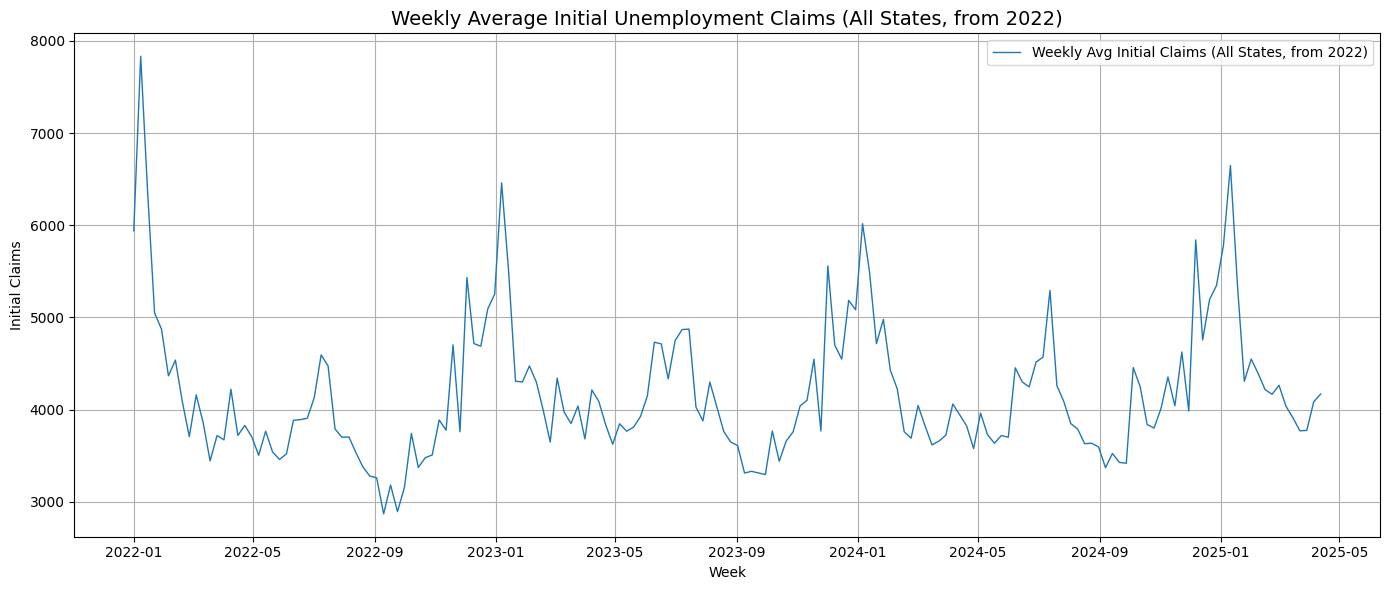

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 기존 df_final이 MultiIndex ['State', 'Filed week ended']로 되어 있다고 가정
# 먼저 인덱스를 풀고 주차별 평균 계산
df_reset = df_final.reset_index()

# 주차별 전체 주 평균 계산
weekly_avg = df_reset.groupby('Filed week ended')['Initial Claims'].mean()

# 2022년 1월 1일 이후 데이터만 필터링
weekly_avg_filtered = weekly_avg[weekly_avg.index >= '2022-01-01']

# 시각화
plt.figure(figsize=(14, 6))
plt.plot(weekly_avg_filtered.index, weekly_avg_filtered.values,
         label='Weekly Avg Initial Claims (All States, from 2022)', linewidth=1, color='tab:blue')
plt.title('Weekly Average Initial Unemployment Claims (All States, from 2022)', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Initial Claims')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


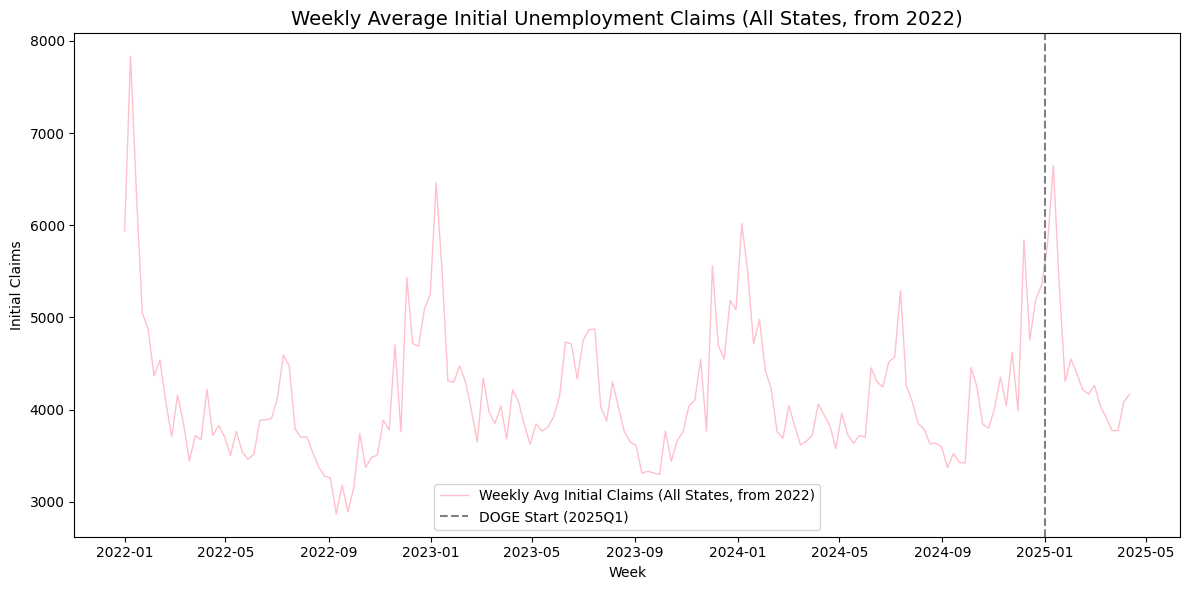

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 주차별 전체 주 평균 계산 (기존 전처리 재사용)
df_reset = df_final.reset_index()
weekly_avg = df_reset.groupby('Filed week ended')['Initial Claims'].mean()

# 2022년 이후 데이터만 필터링
weekly_avg_filtered = weekly_avg[weekly_avg.index >= '2022-01-01']

# DOGE 정책 시행 시점
doge_start_date = pd.to_datetime('2025-01-01')

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(weekly_avg_filtered.index, weekly_avg_filtered.values,
         label='Weekly Avg Initial Claims (All States, from 2022)', linewidth=1, color='pink')

# 수직선 추가 (DOGE 시행 시점)
plt.axvline(x=doge_start_date, color='grey', linestyle='dashed', linewidth=1.5, label='DOGE Start (2025Q1)')

# 그래프 제목 및 레이블
plt.title('Weekly Average Initial Unemployment Claims (All States, from 2022)', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Initial Claims')
plt.grid(False)
plt.legend()
plt.tight_layout()

plt.show()


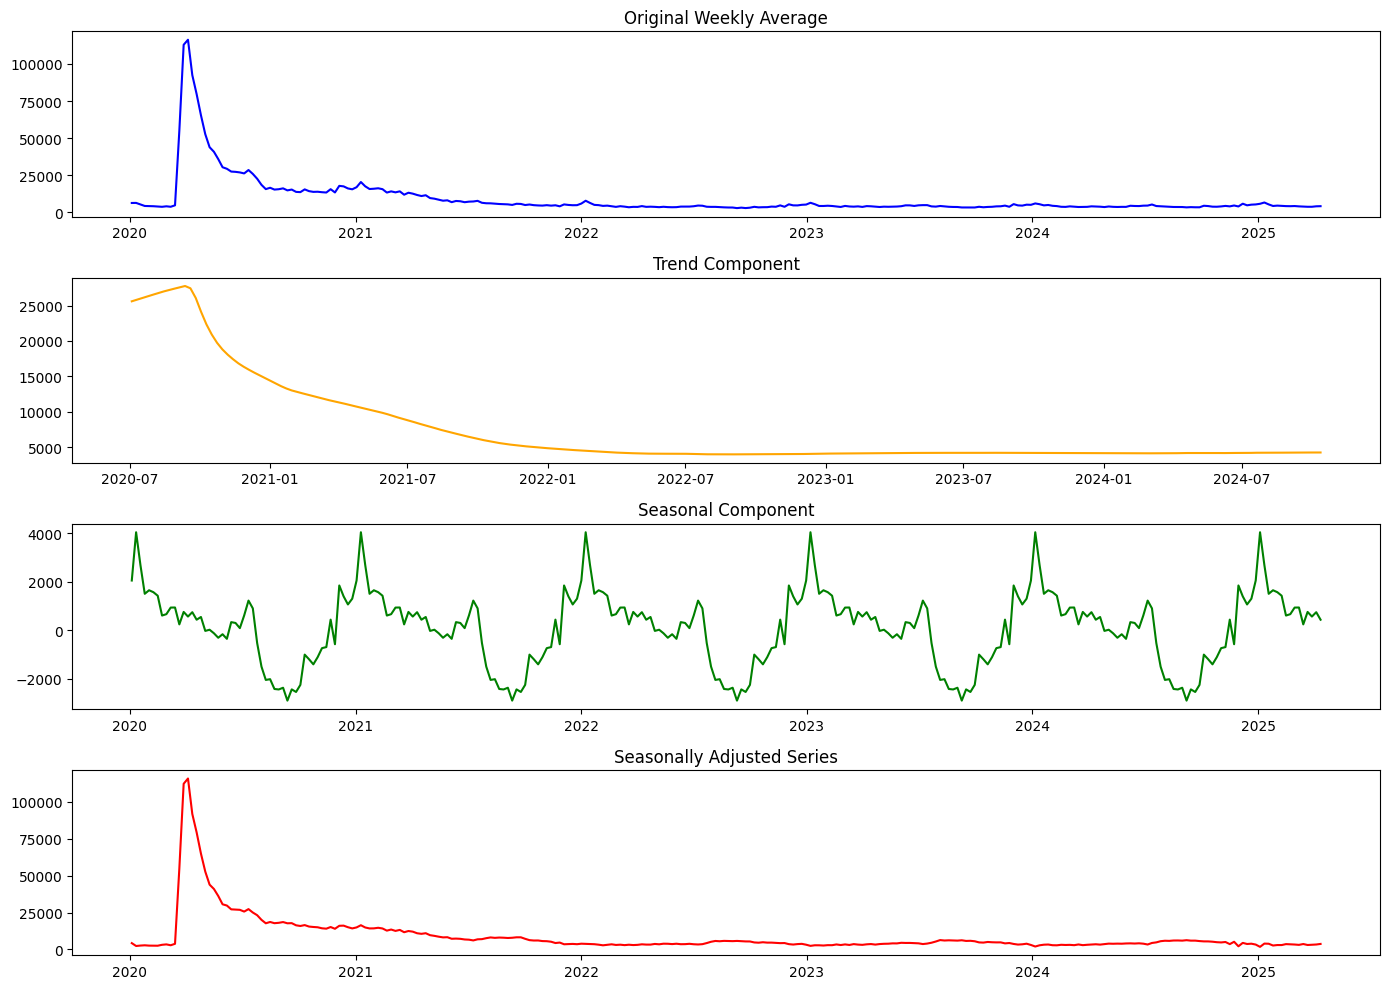

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 전체 주 평균 주차별 시계열 생성 (앞에서 만든 weekly_avg 그대로 사용)
weekly_avg = df_final.reset_index().groupby('Filed week ended')['Initial Claims'].mean()

# 주 단위 시계열로 리샘플링 (정확한 주기적 계절성 분석을 위해 weekly frequency 명시)
weekly_avg = weekly_avg.asfreq('W-SAT')  # 매주 토요일 기준

# 계절 분해 (Additive 모델 사용)
decomposition = seasonal_decompose(weekly_avg, model='additive', period=52)  # 연간 주기

adjusted = weekly_avg - decomposition.seasonal
adjusted_filtered = adjusted[(adjusted.index >= '2022-01-01') & (adjusted.index < '2026-01-01')]

# 분해된 결과 저장
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid
adjusted = weekly_avg - seasonal  # 계절성 제거한 시계열

# 시각화
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(weekly_avg, label='Original', color='blue')
plt.title('Original Weekly Average')

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend', color='orange')
plt.title('Trend Component')

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonality', color='green')
plt.title('Seasonal Component')

plt.subplot(4, 1, 4)
plt.plot(adjusted, label='Seasonally Adjusted', color='red')
plt.title('Seasonally Adjusted Series')

plt.tight_layout()
plt.show()


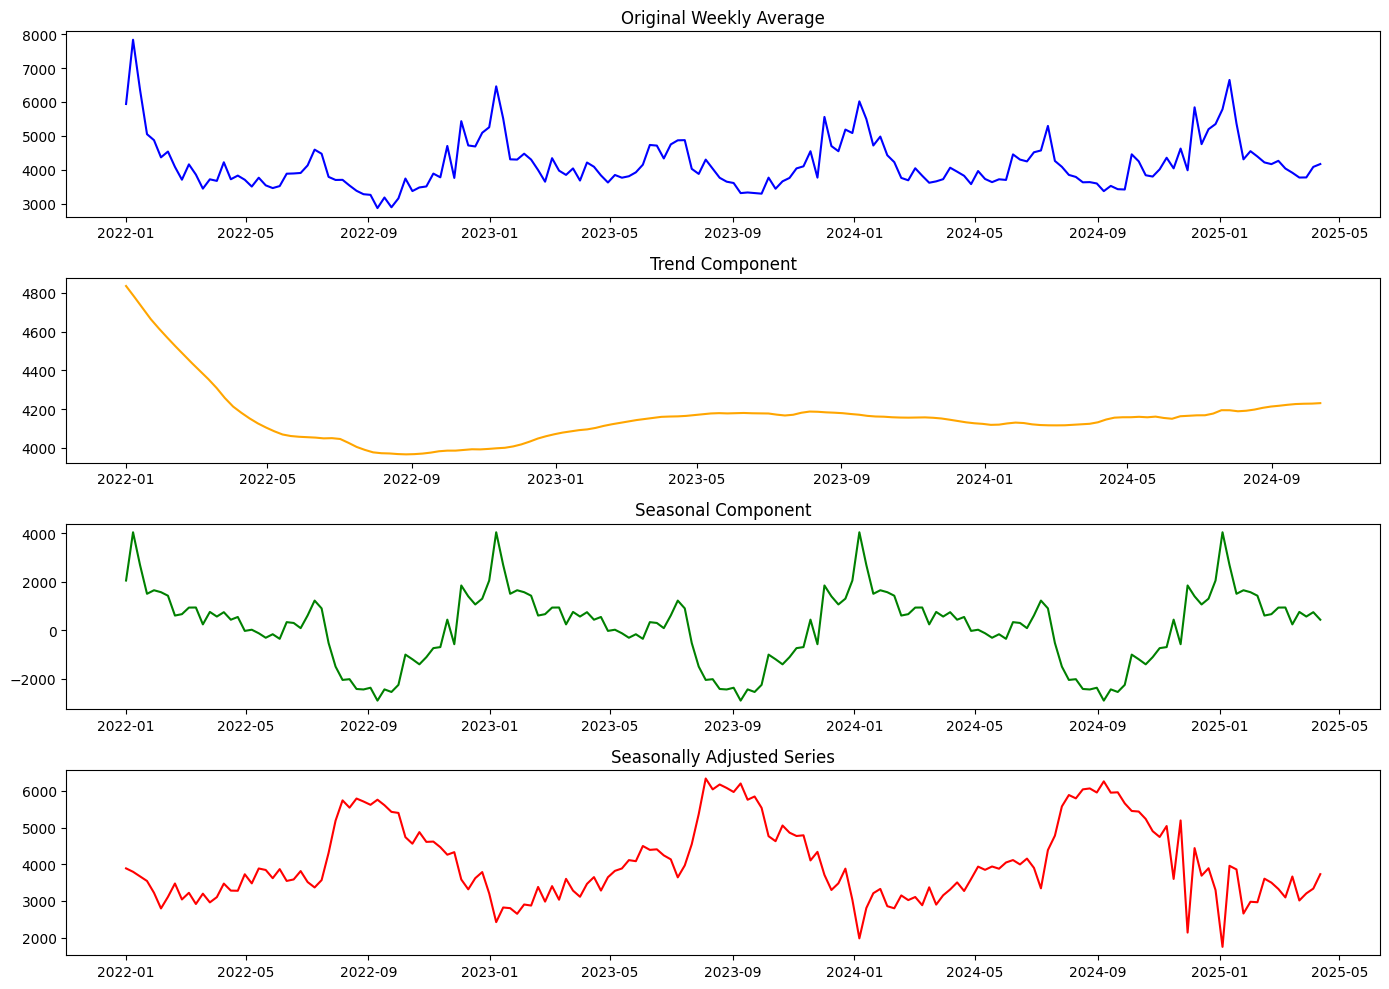

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. 주차별 전체 주 평균 Initial Claims 계산
df_reset = df_final.reset_index()
weekly_avg = df_reset.groupby('Filed week ended')['Initial Claims'].mean()

# 2. 주간 시계열로 설정
weekly_avg = weekly_avg.asfreq('W-SAT')

# 3. 계절 분해 (additive, 52주 주기)
decomposition = seasonal_decompose(weekly_avg, model='additive', period=52)

# 4. 2022~2025년 구간만 필터링
start_date = '2022-01-01'
end_date = '2025-12-31'

original = weekly_avg[(weekly_avg.index >= start_date) & (weekly_avg.index <= end_date)]
trend = decomposition.trend[(decomposition.trend.index >= start_date) & (decomposition.trend.index <= end_date)]
seasonal = decomposition.seasonal[(decomposition.seasonal.index >= start_date) & (decomposition.seasonal.index <= end_date)]
adjusted = (weekly_avg - decomposition.seasonal)[(weekly_avg.index >= start_date) & (weekly_avg.index <= end_date)]

# 5. 시각화
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(original, label='Original Weekly Average', color='blue')
plt.title('Original Weekly Average')

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend Component', color='orange')
plt.title('Trend Component')

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal Component', color='green')
plt.title('Seasonal Component')

plt.subplot(4, 1, 4)
plt.plot(adjusted, label='Seasonally Adjusted Series', color='red')
plt.title('Seasonally Adjusted Series')

plt.tight_layout()
plt.show()


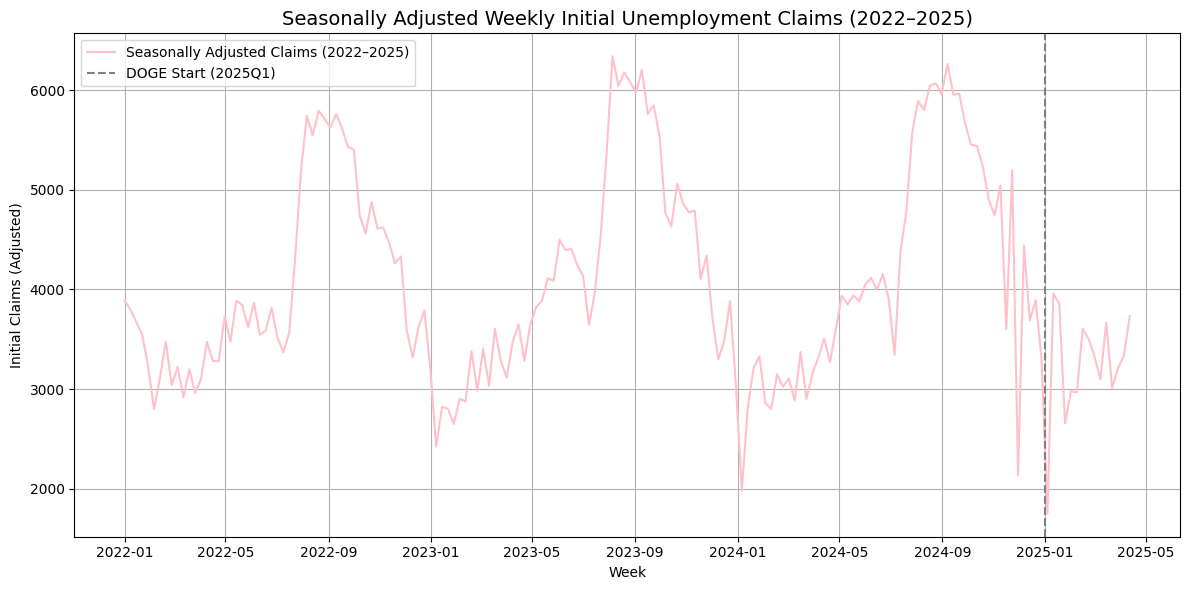

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. 주차별 전체 주 평균 Initial Claims 계산
df_reset = df_final.reset_index()
weekly_avg = df_reset.groupby('Filed week ended')['Initial Claims'].mean()

# 2. 주 단위 시계열로 변환 (주간 빈도 지정)
weekly_avg = weekly_avg.asfreq('W-SAT')  # 매주 토요일 기준 시계열로 설정

# 3. 계절 분해 (Additive 모델, 주기 52주로 설정: 연간 주기)
decomposition = seasonal_decompose(weekly_avg, model='additive', period=52)

# 4. 계절성 제거된 시계열 계산
adjusted = weekly_avg - decomposition.seasonal

# 5. 2022년 1월 ~ 2025년 12월까지만 필터링
adjusted_filtered = adjusted[(adjusted.index >= '2022-01-01') & (adjusted.index < '2026-01-01')]

# 6. 시각화
plt.figure(figsize=(12, 6))
plt.plot(adjusted_filtered.index, adjusted_filtered.values,
         label='Seasonally Adjusted Claims (2022–2025)', color='pink')

# DOGE 정책 시행 시점 표시
plt.axvline(x=pd.to_datetime('2025-01-01'), color='gray', linestyle='--', linewidth=1.5, label='DOGE Start (2025Q1)')

# 그래프 정보
plt.title('Seasonally Adjusted Weekly Initial Unemployment Claims (2022–2025)', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Initial Claims (Adjusted)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


        Week  Y_it (Adjusted Initial Claims)
0 2020-01-04                     4937.582648
1 2020-01-11                     3993.596651
2 2020-01-18                     3844.712066
3 2020-01-25                     3717.047274
4 2020-02-01                     3595.434828


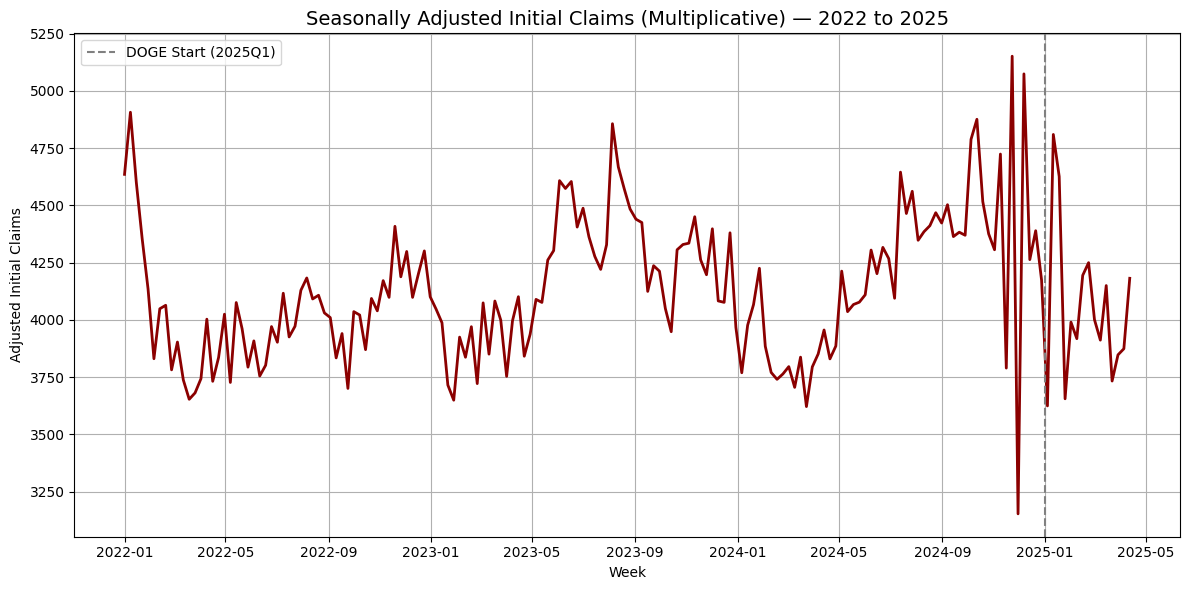

In [15]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: 주별 평균 Initial Claims 생성
df_reset = df_final.reset_index()
weekly_avg = df_reset.groupby('Filed week ended')['Initial Claims'].mean()

# Step 2: 주간 시계열로 설정
weekly_avg = weekly_avg.asfreq('W-SAT')

# Step 3: Multiplicative 모델로 계절 분해
decomposition_mult = seasonal_decompose(weekly_avg, model='multiplicative', period=52)

# Step 4: 계절성 제거 (adjusted 시계열 생성)
adjusted_mult = weekly_avg / decomposition_mult.seasonal

# Step 5: 데이터프레임으로 저장
Y_it_adjusted = pd.DataFrame({
    'Week': adjusted_mult.index,
    'Y_it (Adjusted Initial Claims)': adjusted_mult.values
}).dropna()

# Step 6: CSV 파일로 저장 (선택)
#Y_it_adjusted.to_csv("Y_it_adjusted_initial_claims.csv", index=False)

# 미리보기
print(Y_it_adjusted.head())


# CSV 파일로 저장한 경우에는 아래처럼 불러와도 됨
# Y_it_adjusted = pd.read_csv("Y_it_adjusted_initial_claims.csv", parse_dates=['Week'])

# 2022–2025년 데이터만 필터링
Y_it_filtered = Y_it_adjusted[
    (Y_it_adjusted['Week'] >= '2022-01-01') & 
    (Y_it_adjusted['Week'] <= '2025-12-31')
]

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(Y_it_filtered['Week'], Y_it_filtered['Y_it (Adjusted Initial Claims)'], color='darkred', linewidth=2)
plt.title('Seasonally Adjusted Initial Claims (Multiplicative) — 2022 to 2025', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Adjusted Initial Claims')
plt.grid(True)
plt.axvline(pd.to_datetime('2025-01-01'), color='gray', linestyle='--', label='DOGE Start (2025Q1)')
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: 원본 데이터 준비
df_reset = df_final.reset_index()
states = df_reset['State'].unique()

# 결과 저장할 리스트
adjusted_list = []

# Step 2: 주별로 시계열을 만들어서 계절성 분리
for state in states:
    state_df = df_reset[df_reset['State'] == state].copy()
    state_series = state_df.set_index('Filed week ended')['Initial Claims'].asfreq('W-SAT')
    
    # 데이터가 충분한 경우만 처리 (52주 이상 필요)
    if len(state_series.dropna()) < 104:
        continue
    
    try:
        # Multiplicative 계절 분해
        decomposition = seasonal_decompose(state_series, model='multiplicative', period=52)
        adjusted_series = state_series / decomposition.seasonal

        # 결과 정리
        temp_df = pd.DataFrame({
            'State': state,
            'Week': adjusted_series.index,
            'Adjusted Initial Claims': adjusted_series.values
        }).dropna()

        adjusted_list.append(temp_df)

    except:
        continue  # 분해 실패하는 주는 패스

# Step 3: 전체 주 데이터 합치기
Y_it_full = pd.concat(adjusted_list, ignore_index=True)

# Step 4: 최종 정리
Y_it_full = Y_it_full[['State', 'Week', 'Adjusted Initial Claims']]

# (선택) CSV로 저장
Y_it_full.to_csv("Y_it_multiplicative_adjusted_full.csv", index=False)

# 미리보기
print(Y_it_full.head())


     State       Week  Adjusted Initial Claims
0  Alabama 2020-01-04              4574.474055
1  Alabama 2020-01-11              2493.642297
2  Alabama 2020-01-18              1927.773356
3  Alabama 2020-01-25              1658.179686
4  Alabama 2020-02-01              1666.871836


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error

# 1. 주별 평균 Initial Claims 시계열 생성
df_reset = df_final.reset_index()
weekly_avg = df_reset.groupby('Filed week ended')['Initial Claims'].mean()

# 주간 시계열로 설정
weekly_avg = weekly_avg.asfreq('W-SAT')

# 2. Additive 분해
decomposition_add = seasonal_decompose(weekly_avg, model='additive', period=52)
reconstructed_add = decomposition_add.trend + decomposition_add.resid  # trend + residual

# 3. Multiplicative 분해
decomposition_mult = seasonal_decompose(weekly_avg, model='multiplicative', period=52)
reconstructed_mult = decomposition_mult.trend * decomposition_mult.resid  # trend × residual

# 4. 공통 구간(둘 다 값이 있는 구간)만 비교
valid_index = weekly_avg.index.intersection(reconstructed_add.dropna().index).intersection(reconstructed_mult.dropna().index)

original = weekly_avg.loc[valid_index]
reconstructed_add = reconstructed_add.loc[valid_index]
reconstructed_mult = reconstructed_mult.loc[valid_index]

# 5. RMSE 계산
rmse_add = np.sqrt(mean_squared_error(original, reconstructed_add))
rmse_mult = np.sqrt(mean_squared_error(original, reconstructed_mult))

print(f"Additive Model RMSE: {rmse_add:.2f}")
print(f"Multiplicative Model RMSE: {rmse_mult:.2f}")

# 6. 결과 해석
if rmse_add < rmse_mult:
    print("✅ Additive 모델이 더 잘 맞습니다.")
else:
    print("✅ Multiplicative 모델이 더 잘 맞습니다.")


Additive Model RMSE: 1516.06
Multiplicative Model RMSE: 1336.88
✅ Multiplicative 모델이 더 잘 맞습니다.


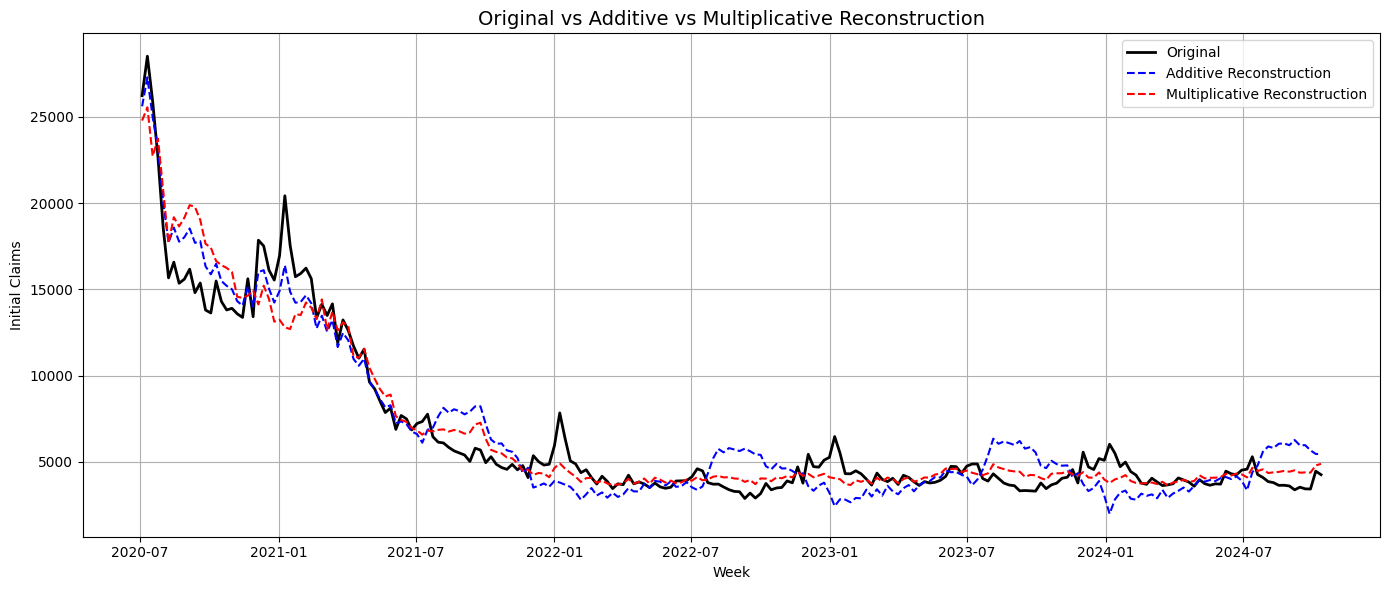

In [18]:
import matplotlib.pyplot as plt

# 1. 공통 valid index는 이미 있으니까 바로 시각화
plt.figure(figsize=(14, 6))

# 원본 시계열
plt.plot(original.index, original.values, label='Original', color='black', linewidth=2)

# Additive 복원 시계열
plt.plot(reconstructed_add.index, reconstructed_add.values, label='Additive Reconstruction', linestyle='--', color='blue')

# Multiplicative 복원 시계열
plt.plot(reconstructed_mult.index, reconstructed_mult.values, label='Multiplicative Reconstruction', linestyle='--', color='red')

# 그래프 세팅
plt.title('Original vs Additive vs Multiplicative Reconstruction', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Initial Claims')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: (다시) 원본 데이터 준비
file_path = 'r539cy.xls'  # 네가 올린 원본 파일 경로
dfs = pd.read_html(file_path)
df = dfs[0]
df.columns = df.iloc[1]
df = df.drop([0, 1]).reset_index(drop=True)
df = df[['State', 'Filed week ended', 'Initial Claims']]
df['Filed week ended'] = pd.to_datetime(df['Filed week ended'])
df['Initial Claims'] = pd.to_numeric(df['Initial Claims'], errors='coerce')
df_final = df.set_index(['State', 'Filed week ended'])

# Step 2: 주별 Multiplicative Seasonal Adjustment
adjusted_by_state = {}
states = df_final.index.get_level_values('State').unique()

for state in states:
    state_df = df_final.loc[state]
    state_series = state_df['Initial Claims'].asfreq('W-SAT')
    
    if len(state_series.dropna()) < 104:
        continue
    
    try:
        decomposition = seasonal_decompose(state_series, model='multiplicative', period=52)
        adjusted = state_series / decomposition.seasonal
        adjusted_by_state[state] = adjusted
    except:
        continue

# Step 3: 2024년과 2025년 평균 비교
increase_ratio_by_state = {}

for state, series in adjusted_by_state.items():
    avg_2024 = series[(series.index >= '2024-01-01') & (series.index < '2025-01-01')].mean()
    avg_2025 = series[(series.index >= '2025-01-01') & (series.index < '2026-01-01')].mean()
    
    if not pd.isna(avg_2024) and not pd.isna(avg_2025) and avg_2024 != 0:
        increase_ratio = (avg_2025 - avg_2024) / avg_2024
        increase_ratio_by_state[state] = increase_ratio

# Step 4: 상위 10개 주 추출
top10_increase_states = pd.Series(increase_ratio_by_state).sort_values(ascending=False).head(10)
print(top10_increase_states.round(2))


District of Columbia    0.78
Kentucky                0.24
New Mexico              0.18
Virginia                0.14
Missouri                0.12
Nebraska                0.08
Colorado                0.07
Illinois                0.07
Michigan                0.07
Puerto Rico             0.07
dtype: float64


In [1]:
import pandas as pd

# 1. 파일 경로 설정
file_path = 'r539cy.xls'  # 파일 경로를 로컬 또는 Colab 환경에 맞게 지정

# 2. HTML 테이블로 읽기 (xls 파일이 HTML 기반일 경우)
dfs = pd.read_html(file_path)
df = dfs[0]

# 3. 헤더 재설정 및 불필요한 행 제거
df.columns = df.iloc[1]  # 두 번째 행을 헤더로 설정
df = df.drop([0, 1]).reset_index(drop=True)

# 4. 필요한 열만 추출
df = df[['State', 'Filed week ended', 'Initial Claims']]

# 5. 데이터 타입 정리
df['Filed week ended'] = pd.to_datetime(df['Filed week ended'])
df['Initial Claims'] = pd.to_numeric(df['Initial Claims'], errors='coerce')

# 6. 정렬 및 패널 형태로 설정
df_final = df.sort_values(by=['State', 'Filed week ended']).reset_index(drop=True)
df_final = df_final.set_index(['State', 'Filed week ended'])

# 7. 결과 확인
print(df_final.head(10))

# 8. (선택) CSV로 저장
df_final.to_csv("Y_it_initial_claims_panel.csv")


1                         Initial Claims
State   Filed week ended                
Alabama 2020-01-04                  4578
        2020-01-11                  3629
        2020-01-18                  2483
        2020-01-25                  2129
        2020-02-01                  2170
        2020-02-08                  2176
        2020-02-15                  1981
        2020-02-22                  1735
        2020-02-29                  1575
        2020-03-07                  1663


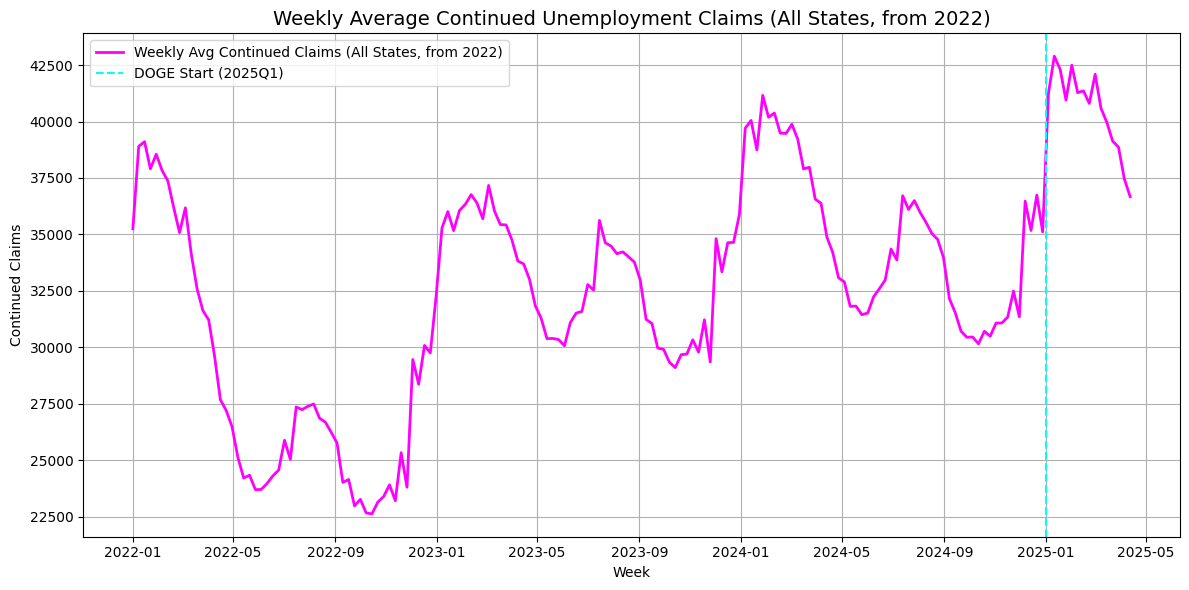

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# 기존 df_final이 MultiIndex ['State', 'Filed week ended']로 되어 있다고 가정
# 먼저 인덱스를 풀고 주차별 평균 계산
df_reset = df_final.reset_index()

# 주차별 전체 주 평균 계산
weekly_avg = df_reset.groupby('Filed week ended')['Continued Claims'].mean()

# 2022년 1월 1일 이후 데이터만 필터링
weekly_avg_filtered = weekly_avg[weekly_avg.index >= '2022-01-01']

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(weekly_avg_filtered.index, weekly_avg_filtered.values,
         label='Weekly Avg Continued Claims (All States, from 2022)', linewidth=2, color='Magenta')
plt.title('Weekly Average Continued Unemployment Claims (All States, from 2022)', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Continued Claims')
plt.axvline(x=doge_start_date, color='cyan', linestyle='dashed', linewidth=1.5, label='DOGE Start (2025Q1)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


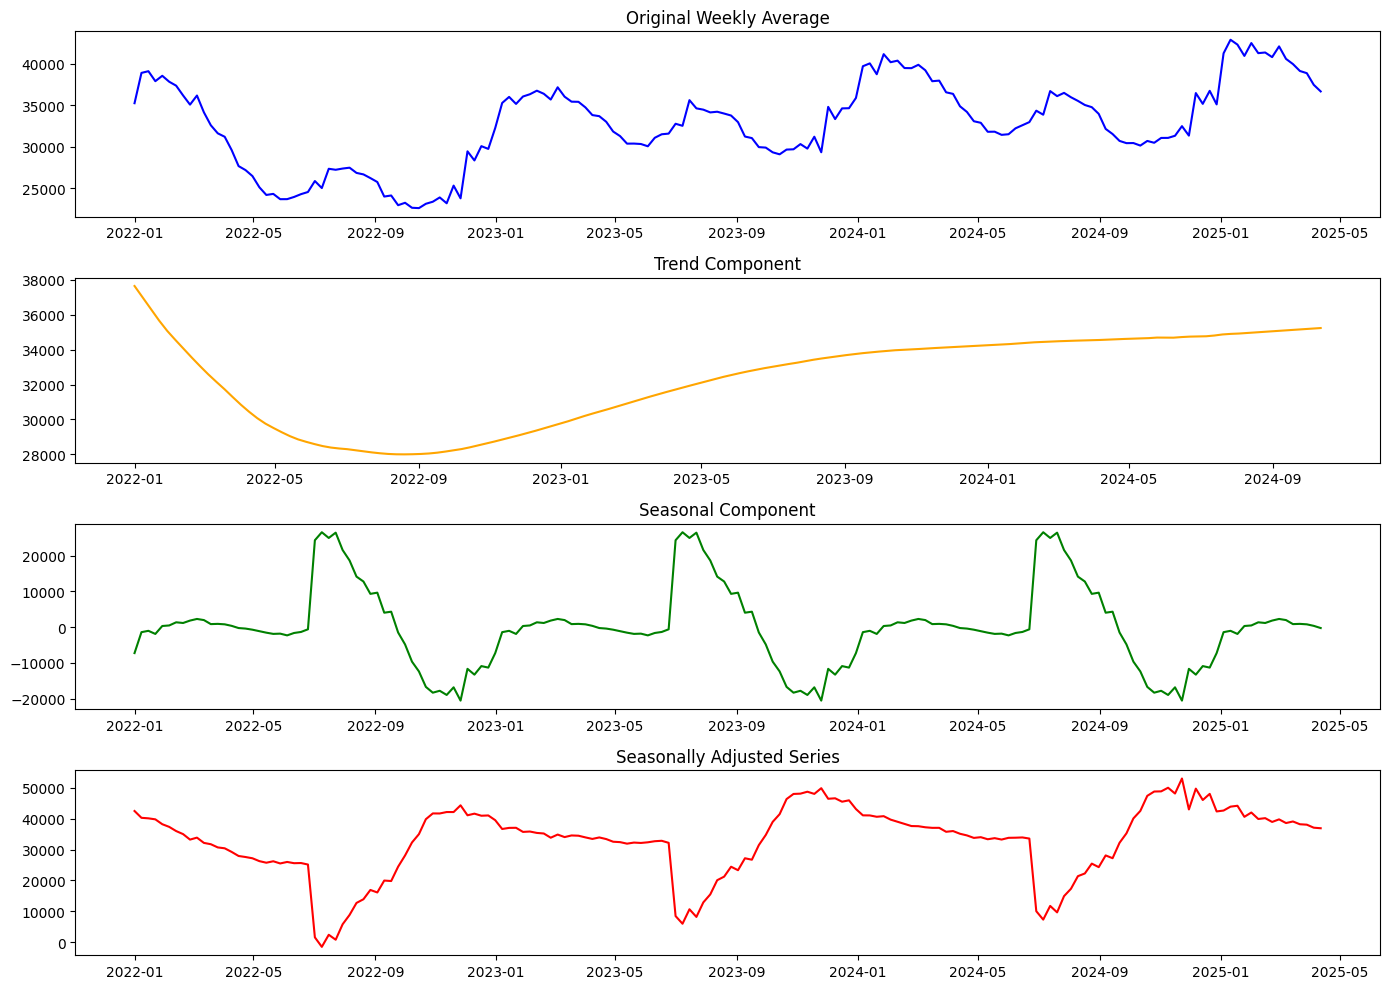

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. 주차별 전체 주 평균 Initial Claims 계산
df_reset = df_final.reset_index()
weekly_avg = df_reset.groupby('Filed week ended')['Continued Claims'].mean()

# 2. 주간 시계열로 설정
weekly_avg = weekly_avg.asfreq('W-SAT')

# 3. 계절 분해 (additive, 52주 주기)
decomposition = seasonal_decompose(weekly_avg, model='Additive', period=52)

# 4. 2022~2025년 구간만 필터링
start_date = '2022-01-01'
end_date = '2025-12-31'

original = weekly_avg[(weekly_avg.index >= start_date) & (weekly_avg.index <= end_date)]
trend = decomposition.trend[(decomposition.trend.index >= start_date) & (decomposition.trend.index <= end_date)]
seasonal = decomposition.seasonal[(decomposition.seasonal.index >= start_date) & (decomposition.seasonal.index <= end_date)]
adjusted = (weekly_avg - decomposition.seasonal)[(weekly_avg.index >= start_date) & (weekly_avg.index <= end_date)]

# 5. 시각화
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(original, label='Original Weekly Average', color='blue')
plt.title('Original Weekly Average')

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend Component', color='orange')
plt.title('Trend Component')

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal Component', color='green')
plt.title('Seasonal Component')

plt.subplot(4, 1, 4)
plt.plot(adjusted, label='Seasonally Adjusted Series', color='red')
plt.title('Seasonally Adjusted Series')

plt.tight_layout()
plt.show()


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error

# 1. 주별 평균 Initial Claims 시계열 생성
df_reset = df_final.reset_index()
weekly_avg = df_reset.groupby('Filed week ended')['Continued Claims'].mean()

# 주간 시계열로 설정
weekly_avg = weekly_avg.asfreq('W-SAT')

# 2. Additive 분해
decomposition_add = seasonal_decompose(weekly_avg, model='additive', period=52)
reconstructed_add = decomposition_add.trend + decomposition_add.resid  # trend + residual

# 3. Multiplicative 분해
decomposition_mult = seasonal_decompose(weekly_avg, model='multiplicative', period=52)
reconstructed_mult = decomposition_mult.trend * decomposition_mult.resid  # trend × residual

# 4. 공통 구간(둘 다 값이 있는 구간)만 비교
valid_index = weekly_avg.index.intersection(reconstructed_add.dropna().index).intersection(reconstructed_mult.dropna().index)

original = weekly_avg.loc[valid_index]
reconstructed_add = reconstructed_add.loc[valid_index]
reconstructed_mult = reconstructed_mult.loc[valid_index]

# 5. RMSE 계산
rmse_add = np.sqrt(mean_squared_error(original, reconstructed_add))
rmse_mult = np.sqrt(mean_squared_error(original, reconstructed_mult))

print(f"Additive Model RMSE: {rmse_add:.2f}")
print(f"Multiplicative Model RMSE: {rmse_mult:.2f}")

# 6. 결과 해석
if rmse_add < rmse_mult:
    print("✅ Additive 모델이 더 잘 맞습니다.")
else:
    print("✅ Multiplicative 모델이 더 잘 맞습니다.")


Additive Model RMSE: 11957.25
Multiplicative Model RMSE: 9587.86
✅ Multiplicative 모델이 더 잘 맞습니다.


        Week  Y_it (Adjusted Continued Claims)
0 2020-01-04                      41272.992546
1 2020-01-11                      39132.404746
2 2020-01-18                      36868.870377
3 2020-01-25                      36687.277489
4 2020-02-01                      36557.472496


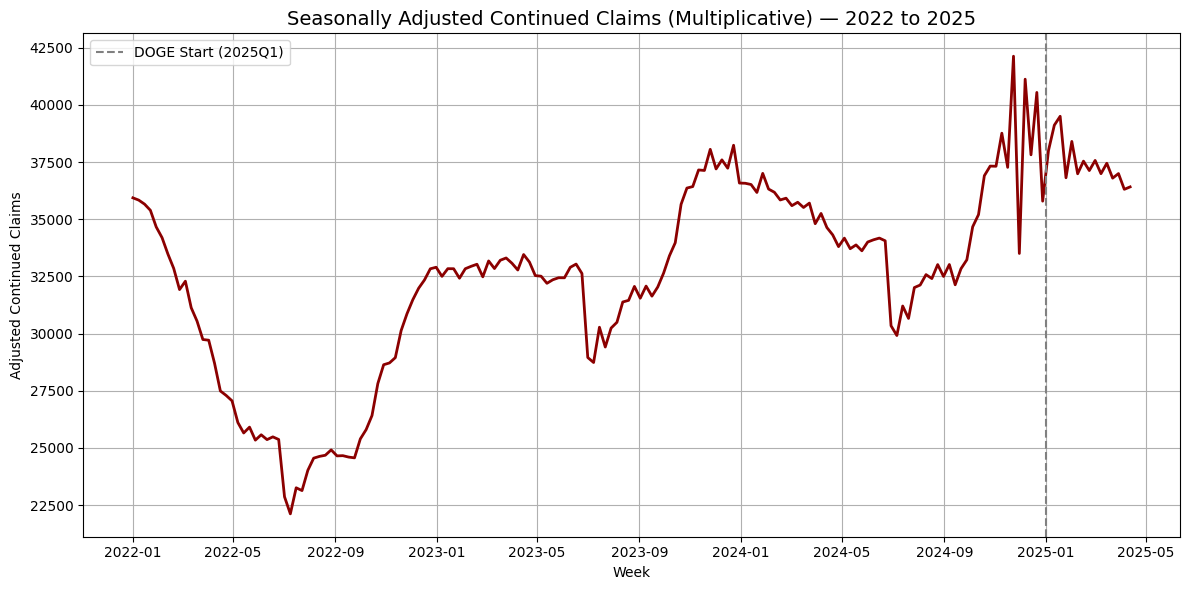

In [41]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: 주별 평균 Initial Claims 생성
df_reset = df_final.reset_index()
weekly_avg = df_reset.groupby('Filed week ended')['Continued Claims'].mean()

# Step 2: 주간 시계열로 설정
weekly_avg = weekly_avg.asfreq('W-SAT')

# Step 3: Multiplicative 모델로 계절 분해
decomposition_mult = seasonal_decompose(weekly_avg, model='multiplicative', period=52)

# Step 4: 계절성 제거 (adjusted 시계열 생성)
adjusted_mult = weekly_avg / decomposition_mult.seasonal

# Step 5: 데이터프레임으로 저장
Y_it_Con_adjusted = pd.DataFrame({
    'Week': adjusted_mult.index,
    'Y_it (Adjusted Continued Claims)': adjusted_mult.values
}).dropna()

# Step 6: CSV 파일로 저장 (선택)
#Y_it_Con_adjusted.to_csv("Y_it_adjusted_Continued_claims.csv", index=False)

# 미리보기
print(Y_it_Con_adjusted.head())


# CSV 파일로 저장한 경우에는 아래처럼 불러와도 됨
# Y_it_adjusted = pd.read_csv("Y_it_adjusted_initial_claims.csv", parse_dates=['Week'])

# 2022–2025년 데이터만 필터링
Y_it_Con_filtered = Y_it_Con_adjusted[
    (Y_it_Con_adjusted['Week'] >= '2022-01-01') & 
    (Y_it_Con_adjusted['Week'] <= '2025-12-31')
]

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(Y_it_Con_filtered['Week'], Y_it_Con_filtered['Y_it (Adjusted Continued Claims)'], color='darkred', linewidth=2)
plt.title('Seasonally Adjusted Continued Claims (Multiplicative) — 2022 to 2025', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Adjusted Continued Claims')
plt.grid(True)
plt.axvline(pd.to_datetime('2025-01-01'), color='gray', linestyle='--', label='DOGE Start (2025Q1)')
plt.legend()
plt.tight_layout()
plt.show()


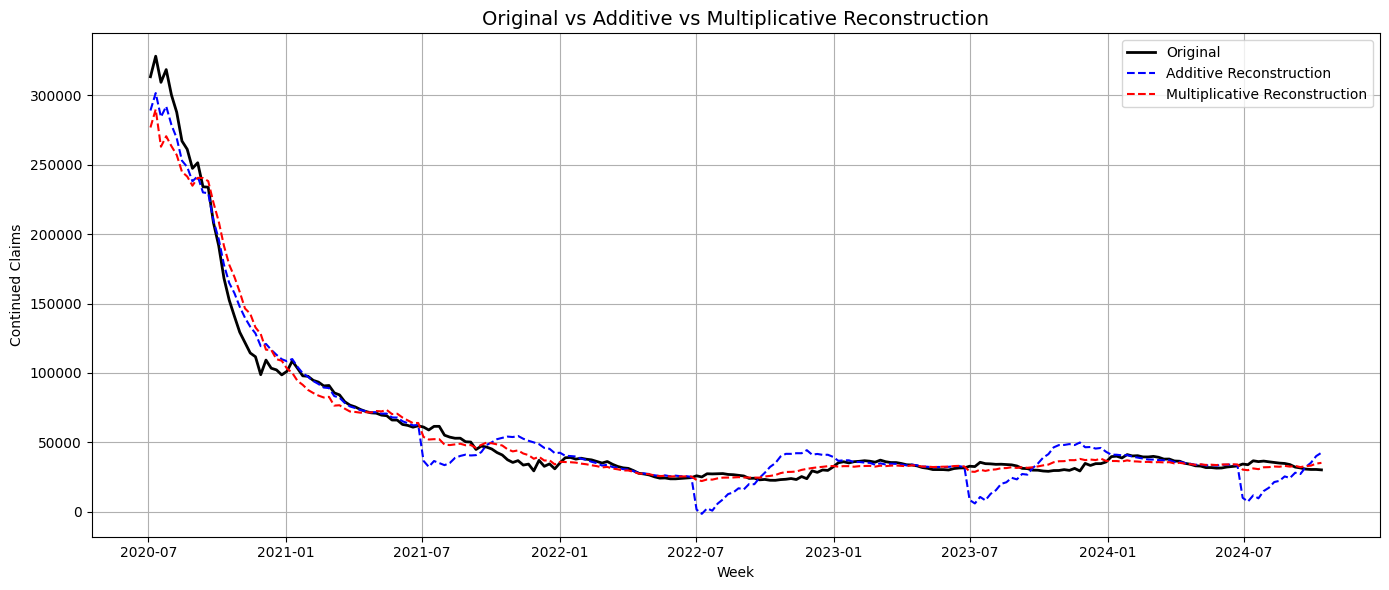

In [38]:
import matplotlib.pyplot as plt

# 1. 공통 valid index는 이미 있으니까 바로 시각화
plt.figure(figsize=(14, 6))

# 원본 시계열
plt.plot(original.index, original.values, label='Original', color='black', linewidth=2)

# Additive 복원 시계열
plt.plot(reconstructed_add.index, reconstructed_add.values, label='Additive Reconstruction', linestyle='--', color='blue')

# Multiplicative 복원 시계열
plt.plot(reconstructed_mult.index, reconstructed_mult.values, label='Multiplicative Reconstruction', linestyle='--', color='red')

# 그래프 세팅
plt.title('Original vs Additive vs Multiplicative Reconstruction', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Continued Claims')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: (다시) 원본 데이터 준비
file_path = 'r539cy.xls'  # 네가 올린 원본 파일 경로
dfs = pd.read_html(file_path)
df = dfs[0]
df.columns = df.iloc[1]
df = df.drop([0, 1]).reset_index(drop=True)
df = df[['State', 'Filed week ended', 'Continued Claims']]
df['Filed week ended'] = pd.to_datetime(df['Filed week ended'])
df['Continued Claims'] = pd.to_numeric(df['Continued Claims'], errors='coerce')
df_final = df.set_index(['State', 'Filed week ended'])

# Step 2: 주별 Multiplicative Seasonal Adjustment
adjusted_by_state = {}
states = df_final.index.get_level_values('State').unique()

for state in states:
    state_df = df_final.loc[state]
    state_series = state_df['Continued Claims'].asfreq('W-SAT')
    
    if len(state_series.dropna()) < 104:
        continue
    
    try:
        decomposition = seasonal_decompose(state_series, model='multiplicative', period=52)
        adjusted = state_series / decomposition.seasonal
        adjusted_by_state[state] = adjusted
    except:
        continue

# Step 3: 2024년과 2025년 평균 비교
increase_ratio_by_state = {}

for state, series in adjusted_by_state.items():
    avg_2024 = series[(series.index >= '2024-01-01') & (series.index < '2025-01-01')].mean()
    avg_2025 = series[(series.index >= '2025-01-01') & (series.index < '2026-01-01')].mean()
    
    if not pd.isna(avg_2024) and not pd.isna(avg_2025) and avg_2024 != 0:
        increase_ratio = (avg_2025 - avg_2024) / avg_2024
        increase_ratio_by_state[state] = increase_ratio

# Step 4: 상위 10개 주 추출
top10_increase_states = pd.Series(increase_ratio_by_state).sort_values(ascending=False).head(10)
print(top10_increase_states.round(2))


Kansas                  0.66
District of Columbia    0.61
Virginia                0.24
Kentucky                0.20
North Carolina          0.19
Michigan                0.17
Washington              0.14
Oregon                  0.14
Illinois                0.13
Montana                 0.12
dtype: float64
